In [23]:
import json
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

In [24]:
@dataclass
class Config:
    project_root: Path = Path.cwd()
    train_years: Tuple[int, ...] = tuple(range(2001, 2019))
    val_years: Tuple[int, ...] = (2019, 2020)
    input_days: int = 4
    forecast_horizon: int = 7
    soil_moisture_feature_index: int = 2
    batch_size: int = 32
    num_epochs: int = 20
    learning_rate: float = 1e-3
    base_filters: int = 32
    num_workers: int = 0
    eps: float = 1e-6
    seed: int = 42
    save_dir_name: str = "outputs_attention_unet_7days"
    best_checkpoint_name: str = "best_attention_unet_model.pth"
    final_checkpoint_name: str = "last_attention_unet_model.pth"
    metrics_name: str = "validation_metrics_best.json"
    history_name: str = "training_history.json"
    prediction_tag: str = "validation"

    @property
    def feature_dirs(self) -> Dict[str, Path]:
        return {
            "evaporation": self.project_root / "yearly_data_evaporation",
            "rainfall": self.project_root / "yearly_data_rainfall",
            "soil_moisture": self.project_root / "yearly_data_soil_moisture",
            "surface_solar_rad": self.project_root / "yearly_data_surface_solar_rad",
            "u_component": self.project_root / "yearly_data_u_component",
            "v_component": self.project_root / "yearly_data_v_component",
        }

    @property
    def mask_path(self) -> Path:
        return self.project_root / "WB_mask.npy"

    @property
    def save_dir(self) -> Path:
        return self.project_root / self.save_dir_name

In [25]:
def seed_everything(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def print_dataset_summary(config: Config) -> None:
    print("Feature directories:")
    for name, directory in config.feature_dirs.items():
        file_count = len(list(directory.glob("yearly_data_*.npy")))
        print(f"  {name:<18} -> {file_count} files")
    print(f"Mask path: {config.mask_path}")

In [26]:
def load_feature_file(directory: Path, year: int) -> np.ndarray:
    file_path = directory / f"yearly_data_{year}.npy"
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")
    array = np.load(file_path).astype(np.float32)
    if array.ndim == 2:
        array = array[np.newaxis, ...]
    if array.ndim != 3:
        raise ValueError(f"Expected shape (days, H, W), got {array.shape} for {file_path}")
    return array


def load_year_stack(config: Config, year: int) -> np.ndarray:
    feature_arrays = [load_feature_file(directory, year) for directory in config.feature_dirs.values()]
    min_days = min(array.shape[0] for array in feature_arrays)
    feature_arrays = [array[:min_days] for array in feature_arrays]
    return np.stack(feature_arrays, axis=1).astype(np.float32)


def compute_feature_stats(config: Config, years: Sequence[int]) -> Tuple[np.ndarray, np.ndarray]:
    sums = None
    sq_sums = None
    total_count = 0

    for year in tqdm(years, desc="Computing feature stats"):
        year_data = load_year_stack(config, year)
        if sums is None:
            feature_count = year_data.shape[1]
            sums = np.zeros(feature_count, dtype=np.float64)
            sq_sums = np.zeros(feature_count, dtype=np.float64)
        sums += year_data.sum(axis=(0, 2, 3))
        sq_sums += np.square(year_data, dtype=np.float64).sum(axis=(0, 2, 3))
        total_count += year_data.shape[0] * year_data.shape[2] * year_data.shape[3]

    if sums is None or sq_sums is None or total_count == 0:
        raise ValueError("Training data is empty.")

    mean = sums / total_count
    variance = np.maximum((sq_sums / total_count) - np.square(mean), config.eps)
    std = np.sqrt(variance)
    return mean.astype(np.float32), std.astype(np.float32)


def normalize_features(array: np.ndarray, feature_mean: np.ndarray, feature_std: np.ndarray) -> np.ndarray:
    return (array - feature_mean.reshape(1, -1, 1, 1)) / feature_std.reshape(1, -1, 1, 1)


def denormalize_soil_moisture(
    array: np.ndarray,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
    soil_moisture_feature_index: int,
) -> np.ndarray:
    sm_mean = float(feature_mean[soil_moisture_feature_index])
    sm_std = float(feature_std[soil_moisture_feature_index])
    return (array * sm_std) + sm_mean

In [27]:
class SoilMoistureDataset(Dataset):
    def __init__(
        self,
        config: Config,
        years: Sequence[int],
        feature_mean: np.ndarray,
        feature_std: np.ndarray,
    ) -> None:
        self.config = config
        self.samples: List[Tuple[np.ndarray, int, int]] = []

        for year in tqdm(years, desc="Loading dataset"):
            year_data = load_year_stack(config, year)
            year_data = normalize_features(year_data, feature_mean, feature_std)
            n_days = year_data.shape[0]
            max_start = n_days - config.input_days - config.forecast_horizon + 1
            if max_start <= 0:
                continue
            for start_day in range(max_start):
                self.samples.append((year_data, year, start_day))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        year_data, year, start_day = self.samples[index]

        input_window = year_data[start_day : start_day + self.config.input_days]
        target_window = year_data[
            start_day + self.config.input_days : start_day + self.config.input_days + self.config.forecast_horizon,
            self.config.soil_moisture_feature_index,
            :,
            :,
        ]

        input_tensor = np.transpose(input_window, (1, 0, 2, 3)).reshape(
            -1, input_window.shape[2], input_window.shape[3]
        )

        metadata = {
            "year": year,
            "input_start_day": start_day,
            "target_start_day": start_day + self.config.input_days,
        }

        return (
            torch.tensor(input_tensor, dtype=torch.float32),
            torch.tensor(target_window, dtype=torch.float32),
            metadata,
        )


def build_dataloaders(
    config: Config,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
) -> Tuple[Dataset, Dataset, DataLoader, DataLoader]:
    train_dataset = SoilMoistureDataset(config, config.train_years, feature_mean, feature_std)
    val_dataset = SoilMoistureDataset(config, config.val_years, feature_mean, feature_std)

    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=pin_memory,
    )
    return train_dataset, val_dataset, train_loader, val_loader

In [28]:
# ============================================================================
# 6. Attention U-Net
# ============================================================================


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, gating_channels: int, skip_channels: int, inter_channels: int) -> None:
        super().__init__()
        self.gating_projection = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(inter_channels),
        )
        self.skip_projection = nn.Sequential(
            nn.Conv2d(skip_channels, inter_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(inter_channels),
        )
        self.attention_head = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(inter_channels, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

    def forward(self, gating_signal: torch.Tensor, skip_tensor: torch.Tensor) -> torch.Tensor:
        gating_signal = match_tensor_size(gating_signal, skip_tensor)
        attention_logits = self.gating_projection(gating_signal) + self.skip_projection(skip_tensor)
        attention_map = self.attention_head(attention_logits)
        return skip_tensor * attention_map


def match_tensor_size(source: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
    if source.shape[-2:] != reference.shape[-2:]:
        source = F.interpolate(source, size=reference.shape[-2:], mode="bilinear", align_corners=False)
    return source


class AttentionUNet(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base_filters: int = 32) -> None:
        super().__init__()
        filters = [base_filters, base_filters * 2, base_filters * 4, base_filters * 8]

        self.enc1 = ConvBlock(in_channels, filters[0])
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(filters[0], filters[1])
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(filters[1], filters[2])
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(filters[2], filters[3])

        self.up3 = nn.ConvTranspose2d(filters[3], filters[2], kernel_size=2, stride=2)
        self.att3 = AttentionGate(filters[2], filters[2], filters[1])
        self.dec3 = ConvBlock(filters[2] * 2, filters[2])

        self.up2 = nn.ConvTranspose2d(filters[2], filters[1], kernel_size=2, stride=2)
        self.att2 = AttentionGate(filters[1], filters[1], filters[0])
        self.dec2 = ConvBlock(filters[1] * 2, filters[1])

        self.up1 = nn.ConvTranspose2d(filters[1], filters[0], kernel_size=2, stride=2)
        self.att1 = AttentionGate(filters[0], filters[0], max(filters[0] // 2, 1))
        self.dec1 = ConvBlock(filters[0] * 2, filters[0])

        self.output_head = nn.Conv2d(filters[0], out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        bottleneck = self.bottleneck(self.pool3(enc3))

        dec3 = self.up3(bottleneck)
        dec3 = match_tensor_size(dec3, enc3)
        enc3_att = self.att3(dec3, enc3)
        dec3 = self.dec3(torch.cat([dec3, enc3_att], dim=1))

        dec2 = self.up2(dec3)
        dec2 = match_tensor_size(dec2, enc2)
        enc2_att = self.att2(dec2, enc2)
        dec2 = self.dec2(torch.cat([dec2, enc2_att], dim=1))

        dec1 = self.up1(dec2)
        dec1 = match_tensor_size(dec1, enc1)
        enc1_att = self.att1(dec1, enc1)
        dec1 = self.dec1(torch.cat([dec1, enc1_att], dim=1))

        return self.output_head(dec1)

In [29]:
# ============================================================================
# 7. Training and Validation
# ============================================================================


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: torch.device,
) -> float:
    model.train()
    running_loss = 0.0

    for inputs, targets, _ in tqdm(loader, desc="Training", leave=False):
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(inputs)
        loss = loss_fn(predictions, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / max(len(loader.dataset), 1)


def compute_masked_metrics(
    predictions_norm: np.ndarray,
    targets_norm: np.ndarray,
    mask: np.ndarray,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
    soil_moisture_feature_index: int,
    eps: float,
) -> Dict[str, Dict[str, float]]:
    predictions = denormalize_soil_moisture(
        predictions_norm,
        feature_mean,
        feature_std,
        soil_moisture_feature_index,
    )
    targets = denormalize_soil_moisture(
        targets_norm,
        feature_mean,
        feature_std,
        soil_moisture_feature_index,
    )

    mask_bool = mask.astype(bool)
    metrics: Dict[str, Dict[str, float]] = {}

    for horizon in range(predictions.shape[1]):
        pred_flat = predictions[:, horizon][:, mask_bool].reshape(-1)
        target_flat = targets[:, horizon][:, mask_bool].reshape(-1)

        mse = float(np.mean((pred_flat - target_flat) ** 2))
        variance = float(np.var(target_flat))
        vr_mse = float(1.0 - (mse / (variance + eps)))
        r2 = float(r2_score(target_flat, pred_flat))

        metrics[f"t+{horizon + 1}"] = {
            "MSE": mse,
            "variance_reduced_MSE": vr_mse,
            "R2": r2,
        }

    pred_all = predictions[:, :, :, :][:, :, mask_bool].reshape(-1)
    target_all = targets[:, :, :, :][:, :, mask_bool].reshape(-1)
    mse_all = float(np.mean((pred_all - target_all) ** 2))
    variance_all = float(np.var(target_all))
    metrics["overall"] = {
        "MSE": mse_all,
        "variance_reduced_MSE": float(1.0 - (mse_all / (variance_all + eps))),
        "R2": float(r2_score(target_all, pred_all)),
    }

    return metrics


def validate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    mask: np.ndarray,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
    config: Config,
) -> Tuple[Dict[str, Dict[str, float]], np.ndarray, np.ndarray, List[Dict[str, int]]]:
    model.eval()
    all_predictions: List[np.ndarray] = []
    all_targets: List[np.ndarray] = []
    metadata_rows: List[Dict[str, int]] = []

    with torch.no_grad():
        for inputs, targets, metadata in tqdm(loader, desc="Validation", leave=False):
            predictions = model(inputs.to(device)).cpu().numpy()
            all_predictions.append(predictions)
            all_targets.append(targets.numpy())

            batch_size = predictions.shape[0]
            for i in range(batch_size):
                start_day = int(metadata["target_start_day"][i])
                metadata_rows.append(
                    {
                        "year": int(metadata["year"][i]),
                        "input_start_day": int(metadata["input_start_day"][i]),
                        "target_start_day": start_day,
                        "target_day_t+1": start_day,
                        "target_day_t+2": start_day + 1,
                        "target_day_t+3": start_day + 2,
                    }
                )

    predictions_norm = np.concatenate(all_predictions, axis=0)
    targets_norm = np.concatenate(all_targets, axis=0)
    metrics = compute_masked_metrics(
        predictions_norm,
        targets_norm,
        mask,
        feature_mean,
        feature_std,
        config.soil_moisture_feature_index,
        config.eps,
    )
    return metrics, predictions_norm, targets_norm, metadata_rows


def save_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
    config: Config,
    epoch: int,
    metrics: Dict[str, Dict[str, float]],
    checkpoint_path: Path,
) -> None:
    payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "feature_mean": feature_mean,
        "feature_std": feature_std,
        "epoch": epoch,
        "metrics": metrics,
        "config": {
            **asdict(config),
            "project_root": str(config.project_root),
            "train_years": list(config.train_years),
            "val_years": list(config.val_years),
        },
    }
    torch.save(payload, checkpoint_path)


def save_validation_predictions(
    predictions_norm: np.ndarray,
    targets_norm: np.ndarray,
    metadata_rows: Sequence[Dict[str, int]],
    mask: np.ndarray,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
    config: Config,
) -> None:
    predictions = denormalize_soil_moisture(
        predictions_norm,
        feature_mean,
        feature_std,
        config.soil_moisture_feature_index,
    )
    targets = denormalize_soil_moisture(
        targets_norm,
        feature_mean,
        feature_std,
        config.soil_moisture_feature_index,
    )

    mask_4d = mask[np.newaxis, np.newaxis, :, :].astype(np.float32)
    masked_predictions = predictions * mask_4d
    masked_targets = targets * mask_4d

    save_path = config.save_dir / f"{config.prediction_tag}_predictions_with_actuals.npz"
    np.savez_compressed(
        save_path,
        predictions=predictions.astype(np.float32),
        actuals=targets.astype(np.float32),
        masked_predictions=masked_predictions.astype(np.float32),
        masked_actuals=masked_targets.astype(np.float32),
        mask=mask.astype(np.uint8),
        year=np.array([row["year"] for row in metadata_rows], dtype=np.int32),
        input_start_day=np.array([row["input_start_day"] for row in metadata_rows], dtype=np.int32),
        target_start_day=np.array([row["target_start_day"] for row in metadata_rows], dtype=np.int32),
        target_day_t1=np.array([row["target_day_t+1"] for row in metadata_rows], dtype=np.int32),
        target_day_t2=np.array([row["target_day_t+2"] for row in metadata_rows], dtype=np.int32),
        target_day_t3=np.array([row["target_day_t+3"] for row in metadata_rows], dtype=np.int32),
    )

    metadata_path = config.save_dir / f"{config.prediction_tag}_prediction_metadata.json"
    metadata_path.write_text(json.dumps(list(metadata_rows), indent=2), encoding="utf-8")


def save_json(data: Dict, path: Path) -> None:
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def plot_training_history(history: Dict[str, List[float]], config: Config) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], marker="o", label="Train MSE")
    plt.plot(epochs, history["val_masked_mse"], marker="s", label="Val masked MSE")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Error")
    plt.title("Attention U-Net Training History")
    plt.legend()
    plt.tight_layout()
    plt.savefig(config.save_dir / "attention_unet_training_history.png", dpi=150)
    plt.close()


def plot_validation_sample(
    predictions_norm: np.ndarray,
    targets_norm: np.ndarray,
    mask: np.ndarray,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
    config: Config,
    sample_index: int = 0,
) -> None:
    predictions = denormalize_soil_moisture(
        predictions_norm[sample_index : sample_index + 1],
        feature_mean,
        feature_std,
        config.soil_moisture_feature_index,
    )[0]
    targets = denormalize_soil_moisture(
        targets_norm[sample_index : sample_index + 1],
        feature_mean,
        feature_std,
        config.soil_moisture_feature_index,
    )[0]

    fig, axes = plt.subplots(2, config.forecast_horizon, figsize=(5 * config.forecast_horizon, 8))
    if config.forecast_horizon == 1:
        axes = np.array(axes).reshape(2, 1)

    for horizon in range(config.forecast_horizon):
        target_map = np.where(mask, targets[horizon], np.nan)
        pred_map = np.where(mask, predictions[horizon], np.nan)
        vmin = np.nanmin([target_map, pred_map])
        vmax = np.nanmax([target_map, pred_map])

        axes[0, horizon].imshow(target_map, cmap="Blues", vmin=vmin, vmax=vmax)
        axes[0, horizon].set_title(f"Actual t+{horizon + 1}")
        axes[0, horizon].axis("off")

        image = axes[1, horizon].imshow(pred_map, cmap="Blues", vmin=vmin, vmax=vmax)
        axes[1, horizon].set_title(f"Predicted t+{horizon + 1}")
        axes[1, horizon].axis("off")

    plt.colorbar(image, ax=axes.ravel().tolist(), label="Soil moisture")
    plt.tight_layout()
    plt.savefig(config.save_dir / "attention_unet_validation_sample.png", dpi=150)
    plt.close()

In [30]:
# ============================================================================
# 8. Inference Helpers
# ============================================================================


def prepare_input_tensor(
    input_window_raw: np.ndarray,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
) -> torch.Tensor:
    if input_window_raw.ndim != 4:
        raise ValueError("Expected input_window_raw with shape (T, F, H, W).")

    normalized = normalize_features(input_window_raw.astype(np.float32), feature_mean, feature_std)
    model_input = np.transpose(normalized, (1, 0, 2, 3)).reshape(
        -1, normalized.shape[2], normalized.shape[3]
    )
    return torch.tensor(model_input[np.newaxis, ...], dtype=torch.float32)


def load_model_for_inference(
    checkpoint_path: Path,
    device: torch.device | None = None,
) -> Tuple[AttentionUNet, Dict, torch.device]:
    if device is None:
        device = get_device()

    checkpoint = torch.load(checkpoint_path, map_location=device)
    saved_config = checkpoint["config"]

    in_channels = len(saved_config["feature_dirs"]) * saved_config["input_days"] if "feature_dirs" in saved_config else 6 * saved_config["input_days"]
    out_channels = saved_config["forecast_horizon"]
    model = AttentionUNet(
        in_channels=in_channels,
        out_channels=out_channels,
        base_filters=saved_config["base_filters"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint, device


def predict_soil_moisture(
    model: AttentionUNet,
    input_window_raw: np.ndarray,
    feature_mean: np.ndarray,
    feature_std: np.ndarray,
    soil_moisture_feature_index: int,
    device: torch.device,
    mask: np.ndarray | None = None,
) -> Dict[str, np.ndarray]:
    input_tensor = prepare_input_tensor(input_window_raw, feature_mean, feature_std).to(device)

    with torch.no_grad():
        predictions_norm = model(input_tensor).cpu().numpy()[0]

    predictions = denormalize_soil_moisture(
        predictions_norm[np.newaxis, ...],
        feature_mean,
        feature_std,
        soil_moisture_feature_index,
    )[0]

    output = {
        "predictions_norm": predictions_norm,
        "predictions": predictions,
    }
    if mask is not None:
        output["masked_predictions"] = predictions * mask[np.newaxis, :, :]
    return output


def predict_from_checkpoint(
    checkpoint_path: Path,
    input_window_raw: np.ndarray,
    mask_path: Path | None = None,
) -> Dict[str, np.ndarray]:
    model, checkpoint, device = load_model_for_inference(checkpoint_path)
    feature_mean = checkpoint["feature_mean"]
    feature_std = checkpoint["feature_std"]
    saved_config = checkpoint["config"]
    mask = np.load(mask_path).astype(np.float32) if mask_path is not None else None

    return predict_soil_moisture(
        model=model,
        input_window_raw=input_window_raw,
        feature_mean=feature_mean,
        feature_std=feature_std,
        soil_moisture_feature_index=saved_config["soil_moisture_feature_index"],
        device=device,
        mask=mask,
    )

In [31]:
# ============================================================================
# 10. Example Inference Usage
# ============================================================================


def example_inference() -> Dict[str, np.ndarray]:
    config = Config()
    checkpoint_path = config.save_dir / config.best_checkpoint_name

    example_year = config.val_years[0]
    year_data = load_year_stack(config, example_year)
    input_window_raw = year_data[: config.input_days]

    outputs = predict_from_checkpoint(
        checkpoint_path=checkpoint_path,
        input_window_raw=input_window_raw,
        mask_path=config.mask_path,
    )

    print("Prediction shapes:")
    for key, value in outputs.items():
        print(f"  {key}: {value.shape}")
    return outputs

In [32]:
# ============================================================================
# 9. Main Training Pipeline
# ============================================================================


def main() -> Dict[str, Dict[str, float]]:
    config = Config()
    ensure_dir(config.save_dir)
    seed_everything(config.seed)
    print_dataset_summary(config)

    device = get_device()
    mask = np.load(config.mask_path).astype(np.float32)
    print(f"Using device: {device}")
    print(f"Mask shape: {mask.shape}, valid pixels: {int(mask.sum())}")

    feature_mean, feature_std = compute_feature_stats(config, config.train_years)
    print("\nFeature-wise normalization statistics:")
    for index, feature_name in enumerate(config.feature_dirs.keys()):
        print(f"  {feature_name:<18} mean={feature_mean[index]:.6f} std={feature_std[index]:.6f}")

    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders(config, feature_mean, feature_std)
    print(f"\nTraining samples:   {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")

    in_channels = len(config.feature_dirs) * config.input_days
    out_channels = config.forecast_horizon
    model = AttentionUNet(in_channels, out_channels, base_filters=config.base_filters).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    loss_fn = nn.MSELoss()

    parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    print(f"Model parameters: {parameter_count:,}")

    history = {
        "train_loss": [],
        "val_masked_mse": [],
        "val_r2": [],
    }

    best_val_mse = float("inf")
    best_metrics: Dict[str, Dict[str, float]] | None = None
    best_predictions_norm = None
    best_targets_norm = None
    best_metadata_rows = None
    best_epoch = 0

    for epoch in range(1, config.num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        metrics, predictions_norm, targets_norm, metadata_rows = validate(
            model,
            val_loader,
            device,
            mask,
            feature_mean,
            feature_std,
            config,
        )

        val_mse = metrics["overall"]["MSE"]
        val_r2 = metrics["overall"]["R2"]
        history["train_loss"].append(train_loss)
        history["val_masked_mse"].append(val_mse)
        history["val_r2"].append(val_r2)

        print(
            f"Epoch {epoch:02d}/{config.num_epochs} | "
            f"train MSE={train_loss:.6f} | "
            f"val masked MSE={val_mse:.6f} | "
            f"val R2={val_r2:.6f}"
        )

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_metrics = metrics
            best_predictions_norm = predictions_norm.copy()
            best_targets_norm = targets_norm.copy()
            best_metadata_rows = list(metadata_rows)
            best_epoch = epoch
            save_checkpoint(
                model,
                optimizer,
                feature_mean,
                feature_std,
                config,
                epoch,
                metrics,
                config.save_dir / config.best_checkpoint_name,
            )
            print(f"  Saved new best model at epoch {epoch}")

    save_checkpoint(
        model,
        optimizer,
        feature_mean,
        feature_std,
        config,
        config.num_epochs,
        metrics,
        config.save_dir / config.final_checkpoint_name,
    )

    if best_metrics is None or best_predictions_norm is None or best_targets_norm is None or best_metadata_rows is None:
        raise RuntimeError("Best model was not captured during training.")

    history["best_epoch"] = best_epoch
    save_json(history, config.save_dir / config.history_name)
    save_json(best_metrics, config.save_dir / config.metrics_name)
    save_validation_predictions(
        best_predictions_norm,
        best_targets_norm,
        best_metadata_rows,
        mask,
        feature_mean,
        feature_std,
        config,
    )
    plot_training_history(history, config)
    plot_validation_sample(
        best_predictions_norm,
        best_targets_norm,
        mask,
        feature_mean,
        feature_std,
        config,
    )

    print("\nBest validation metrics:")
    for key, values in best_metrics.items():
        print(
            f"  {key:<8} "
            f"MSE={values['MSE']:.6f} "
            f"variance_reduced_MSE={values['variance_reduced_MSE']:.6f} "
            f"R2={values['R2']:.6f}"
        )

    print(f"\nBest model saved to: {config.save_dir / config.best_checkpoint_name}")
    print(f"Validation predictions saved to: {config.save_dir / (config.prediction_tag + '_predictions_with_actuals.npz')}")
    return best_metrics


In [33]:
main()

Feature directories:
  evaporation        -> 20 files
  rainfall           -> 20 files
  soil_moisture      -> 20 files
  surface_solar_rad  -> 20 files
  u_component        -> 20 files
  v_component        -> 20 files
Mask path: f:\IIT KGP\sem10\MTP 2\WB_mask.npy
Using device: cpu
Mask shape: (33, 25), valid pixels: 120


Computing feature stats: 100%|██████████| 18/18 [00:00<00:00, 40.13it/s]



Feature-wise normalization statistics:
  evaporation        mean=-0.000124 std=0.001000
  rainfall           mean=0.000217 std=0.001000
  soil_moisture      mean=0.251225 std=0.135366
  surface_solar_rad  mean=783518.937500 std=237707.125000
  u_component        mean=0.091564 std=1.847149
  v_component        mean=0.429594 std=1.909163


Loading dataset: 100%|██████████| 2/2 [00:00<00:00, 55.37it/s]



Training samples:   6394
Validation samples: 711
Model parameters: 1,955,552


...

Epoch 19/20 | train MSE=0.037230 | val masked MSE=0.001540 | val R2=0.843829


Epoch 20/20 | train MSE=0.036060 | val masked MSE=0.001538 | val R2=0.844075


C:\Users\sreya\AppData\Local\Temp\ipykernel_2164\2324157339.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Best validation metrics:
  t+1      MSE=0.000347 variance_reduced_MSE=0.964762 R2=0.964759
  t+2      MSE=0.000750 variance_reduced_MSE=0.923914 R2=0.923907
  t+3      MSE=0.001123 variance_reduced_MSE=0.886060 R2=0.886049
  t+4      MSE=0.001432 variance_reduced_MSE=0.854842 R2=0.854828
  t+5      MSE=0.001649 variance_reduced_MSE=0.832865 R2=0.832848
  t+6      MSE=0.001808 variance_reduced_MSE=0.816927 R2=0.816909
  t+7      MSE=0.001947 variance_reduced_MSE=0.802907 R2=0.802887
  overall  MSE=0.001294 variance_reduced_MSE=0.868831 R2=0.868818

Best model saved to: f:\IIT KGP\sem10\MTP 2\outputs_attention_unet_7days\best_attention_unet_model.pth
Validation predictions saved to: f:\IIT KGP\sem10\MTP 2\outputs_attention_unet_7days\validation_predictions_with_actuals.npz


{'t+1': {'MSE': 0.0003468293871264905,
  'variance_reduced_MSE': 0.9647621099357933,
  'R2': 0.9647585153579712},
 't+2': {'MSE': 0.0007495858008041978,
  'variance_reduced_MSE': 0.9239144128563949,
  'R2': 0.923906683921814},
 't+3': {'MSE': 0.0011232626857236028,
  'variance_reduced_MSE': 0.8860603926853013,
  'R2': 0.8860487937927246},
 't+4': {'MSE': 0.0014317608438432217,
  'variance_reduced_MSE': 0.8548423961795482,
  'R2': 0.8548277020454407},
 't+5': {'MSE': 0.0016493452712893486,
  'variance_reduced_MSE': 0.8328648997668213,
  'R2': 0.8328479528427124},
 't+6': {'MSE': 0.0018075831467285752,
  'variance_reduced_MSE': 0.8169271754105711,
  'R2': 0.8169086575508118},
 't+7': {'MSE': 0.0019473289139568806,
  'variance_reduced_MSE': 0.8029068833861969,
  'R2': 0.802886962890625},
 'overall': {'MSE': 0.0012936708517372608,
  'variance_reduced_MSE': 0.8688312874103121,
  'R2': 0.8688179850578308}}

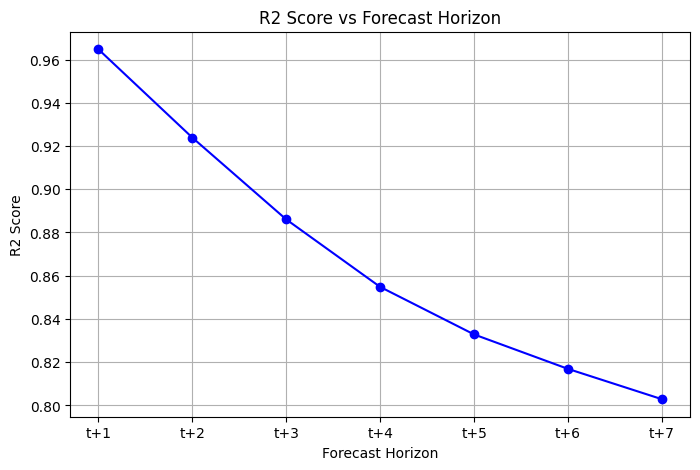

In [37]:
R2 = [
    0.964759, 0.923907, 0.886049, 0.854828, 0.832848, 0.816909, 0.802887]

#plot line graph pf R2 vs t+1, T+2, ..., T+7
import matplotlib.pyplot as plt
horizons = [f"t+{i}" for i in range(1, 8)]
plt.figure(figsize=(8, 5))
plt.plot(horizons, R2, marker='o', linestyle='-', color='blue')
plt.title('R2 Score vs Forecast Horizon')
plt.xlabel('Forecast Horizon')
plt.ylabel('R2 Score')

plt.grid(True)
plt.savefig('r2_score_vs_horizon.png', dpi=150)
plt.show()